# Hospital Readmission Prediction Using Logistic Regression

**Academic Machine Learning Case Study**  
*Department of Computer Science & Engineering / Artificial Intelligence & Machine Learning*

---
### Project Summary:
* **Objective:** Predict 30-day unplanned hospital readmission risk for diabetic inpatient admissions using electronic health records (demographics, ICD-9 diagnosis codes, prior visits/utilization, and clinical vitals/labs).
* **Mandated Algorithm:** **Logistic Regression with L2 Regularization** ($C=1.0$, Ridge penalty) implemented via scikit-learn `Pipeline` and `ColumnTransformer`.
* **Primary Evaluation Metric:** **ROC-AUC** (Area Under the Receiver Operating Characteristic Curve), supplemented by Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
* **Core Investigation:** Clinical cost trade-off between False Negatives (FN) and False Positives (FP) across decision thresholds, and model interpretability via log-odds regression coefficients.


## 2. Problem Statement

### Clinical and Operational Context
Hospital readmissions within 30 days of discharge represent a critical challenge in modern healthcare delivery:
1. **Patient Safety & Health Outcomes:** Unplanned readmissions frequently signal premature discharge, adverse drug events, hospital-acquired complications, or uncoordinated outpatient handoffs.
2. **Financial and Regulatory Penalties:** Under regulatory frameworks such as the **Hospital Readmissions Reduction Program (HRRP)** administered by the Centers for Medicare & Medicaid Services (CMS), hospitals with excessive 30-day readmission rates face substantial reimbursement penalties.
3. **Resource Allocation:** Readmissions place severe strains on inpatient bed availability, nursing staff, and emergency departments.

### Machine Learning Objective
The objective of this case study is to build a binary classification model that takes clinical records from an inpatient encounter and predicts whether the patient will be **readmitted within 30 days** of discharge ($Y=1$) or not ($Y=0$).

The predictive model must:
* Rely on interpretable clinical predictors (diagnosis codes, vitals, prior visit history, medications, length of stay).
* Adhere strictly to **Logistic Regression with L2 regularization** as required by the case study specification.
* Avoid data leakage through proper encapsulation in a scikit-learn `Pipeline`.
* Explicitly analyze the clinical and economic trade-offs of False Positives vs. False Negatives.


## 3. Dataset Description

### Data Source
We utilize the gold-standard, publicly available **Diabetes 130-US Hospitals (1999–2008)** dataset from the **UCI Machine Learning Repository** (Strack et al., 2014):
* **Source:** UCI Machine Learning Repository (Dataset ID: 296).
* **Reference:** Strack, B., DeShazo, J. P., Gennings, C., Olmo, J. L., Ventura, S., Cios, K. J., & Clore, J. N. (2014). *Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records*. BioMed Research International, 2014.
* **Original Dimensions:** 101,766 hospital encounters across 71,518 unique diabetic patients, featuring 50 clinical, demographic, and administrative attributes.

### Key Feature Categories
* **Demographics:** `race`, `gender`, `age` (10-year age brackets).
* **Admission & Stay Characteristics:** `admission_type_id` (Emergency, Urgent, Elective), `discharge_disposition_id`, `admission_source_id`, `time_in_hospital` (length of stay in days, 1–14).
* **Prior Healthcare Utilization (Visits):** `number_outpatient`, `number_emergency`, `number_inpatient` (counts of visits in the year preceding the encounter).
* **Clinical Tests & Vitals:** `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `max_glu_serum` (glucose test results), `A1Cresult` (HbA1c test results).
* **Diagnosis Codes:** `diag_1` (primary diagnosis), `diag_2` (secondary diagnosis), `diag_3` (tertiary diagnosis) coded in ICD-9.
* **Medications:** 24 specific diabetic medications (e.g., `metformin`, `insulin`, `glipizide`, `glyburide`), tracking dosage adjustments (`Up`, `Down`, `Steady`, `No`), plus `change` and `diabetesMed`.

### Target Transformation
The raw target column `readmitted` contains three distinct categories:
* `"<30"`: Patient readmitted within 30 days of discharge.
* `">30"`: Patient readmitted after more than 30 days.
* `"NO"`: No readmission recorded.

To predict **30-day readmission risk**, we strictly formulate this as a binary target:
$$\text{Target } y = \begin{cases} 1 & \text{if } \text{readmitted} = \text{'<30'} \\ 0 & \text{if } \text{readmitted} \in \{\text{'>30'}, \text{'NO'}\} \end{cases}$$


## 4. Import Libraries

We import standard, industry-standard Python libraries for data manipulation, visualization, pipeline construction, model training, and performance evaluation.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn model and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Suppress minor future warnings for clean academic presentation
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


## 5. Load Dataset

We load the dataset from `data/diabetic_data.csv` and inspect its initial shape, column names, data types, and initial records.


In [2]:
data_path = os.path.join("..", "data", "diabetic_data.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "diabetic_data.csv")

raw_df = pd.read_csv(data_path)
print(f"Dataset loaded successfully.")
print(f"Number of rows (encounters): {raw_df.shape[0]:,}")
print(f"Number of columns (features): {raw_df.shape[1]}")


Dataset loaded successfully.
Number of rows (encounters): 101,766
Number of columns (features): 50


In [3]:
# Display first 5 records
raw_df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Column names and data types
print("Dataset Column Information:")
raw_df.info()


Dataset Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num

In [5]:
# Summary statistics for numerical variables
raw_df.describe().T


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [6]:
# In this dataset, missing values are encoded as '?'
print("Missing value analysis (count of '?' per column):")
missing_counts = (raw_df == '?').sum()
missing_pct = (missing_counts / len(raw_df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct.round(2)
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

missing_summary


Missing value analysis (count of '?' per column):


,Missing Count,Percentage (%)
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


## 6. Data Cleaning

Data cleaning decisions follow established clinical epidemiology and machine learning best practices:

1. **Excluding Ineligible Patients:** Patients with `discharge_disposition_id` in `{11, 13, 14, 19, 20, 21}` expired during hospitalization or were discharged to hospice care. Because these patients are clinically ineligible for hospital readmission, keeping them would introduce survival bias.
2. **Mitigating Patient Clustering & Data Leakage:** The raw dataset contains multiple encounters for individual frequent-attender patients (`patient_nbr`). Following Strack et al. (2014), we retain only the **first (index) encounter** for each unique patient. This essential design choice eliminates repeat-encounter correlation for the same individual and strictly prevents the same patient from appearing in both training and testing splits (which would cause data leakage and artificially inflate test metrics). Note that while this removes patient-level repeated measures, it does not claim to make observational EHR data strictly independent and identically distributed (i.i.d.), as underlying hospital-level admission patterns, regional care variation, and secular temporal trends remain present.
3. **Dropping Irrelevant Identifiers:** `encounter_id` and `patient_nbr` are administrative primary keys with zero generalizable predictive value.
4. **Handling Features with Excessive Missingness:** `weight` is missing in >96% of records, and `payer_code` is missing in ~40% and represents billing classification rather than clinical state; both are dropped.
5. **Removing Constant / Zero-Variance Columns:** Features such as `examide` and `citoglipton` have only a single category (`'No'`) across all encounters, offering zero variance.
6. **Handling Missing Clinical Values:** For `race` and `medical_specialty`, missing values (`'?'`) are categorized as `'Missing'` so their predictive signal (e.g., missing specialty often indicates community hospital admission) is preserved.
7. **Target Transformation:** Convert `readmitted` to a binary label (`1` for `'<30'`, `0` for `'>30'` or `'NO'`).


In [7]:
df_clean = raw_df.copy()

# 1. Remove expired and hospice patients
expired_ids = [11, 13, 14, 19, 20, 21]
before_expired = len(df_clean)
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(expired_ids)].copy()
print(f"Removed {before_expired - len(df_clean):,} expired/hospice patient encounters.")

# 2. Keep only the first encounter per patient for independence of observations
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['patient_nbr'], keep='first').copy()
print(f"Deduplicated patients: Retained {len(df_clean):,} unique patient encounters (dropped {before_dedup - len(df_clean):,} repeat visits).")

# 3. Create the binary target variable (<30 -> 1, otherwise 0)
df_clean['target'] = (df_clean['readmitted'] == '<30').astype(int)
print(f"\nBinary Target Distribution:")
print(df_clean['target'].value_counts())
print(f"Readmitted < 30 days: {df_clean['target'].mean():.2%}")
print(f"Not Readmitted < 30 days: {(1 - df_clean['target'].mean()):.2%}")

# 4. Drop non-predictive identifiers and uninformative/zero-variance columns
drop_cols = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'readmitted', 'examide', 'citoglipton']
df_clean = df_clean.drop(columns=[col for col in drop_cols if col in df_clean.columns])

# 5. Handle rare invalid gender entries (only 3 in the entire dataset)
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid'].copy()

# 6. Impute missing race codes '?' with 'Missing'
df_clean['race'] = df_clean['race'].replace('?', 'Missing')

# 7. Clean medical_specialty: keep top 10 specialties, group others into 'Other', '?' into 'Missing'
top_specialties = df_clean['medical_specialty'].value_counts().nlargest(10).index.tolist()
df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(
    lambda x: x if x in top_specialties and x != '?' else ('Missing' if x == '?' else 'Other')
)

# 8. Ensure administrative categorical ID columns are treated as strings
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df_clean[col] = df_clean[col].astype(str)

print(f"Cleaned dataset shape: {df_clean.shape}")


Removed 2,423 expired/hospice patient encounters.


Deduplicated patients: Retained 69,990 unique patient encounters (dropped 29,353 repeat visits).

Binary Target Distribution:
target
0    63705
1     6285
Name: count, dtype: int64
Readmitted < 30 days: 8.98%
Not Readmitted < 30 days: 91.02%


Cleaned dataset shape: (69987, 44)

## 7. Exploratory Data Analysis (EDA)

We explore key clinical variables and their empirical relationship with 30-day readmission:
1. **Target Readmission Distribution:** Quantifying class imbalance.
2. **Age Distribution:** Readmission rate across age brackets.
3. **Prior Utilization:** Prior inpatient, emergency, and outpatient visits.
4. **Length of Stay:** Time spent in the hospital (`time_in_hospital`).
5. **Correlation Analysis:** Pearson correlation matrix among numerical clinical features.


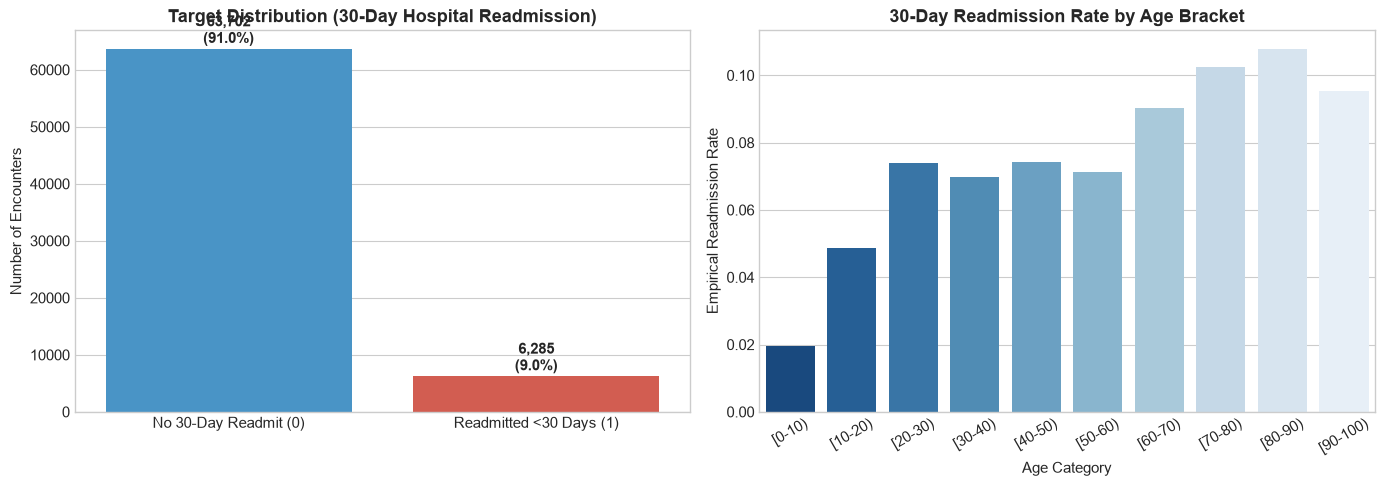

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Class Distribution
target_counts = df_clean['target'].value_counts()
sns.barplot(x=['No 30-Day Readmit (0)', 'Readmitted <30 Days (1)'], 
            y=target_counts.values, 
            palette=['#3498db', '#e74c3c'], 
            ax=axes[0])
axes[0].set_title('Target Distribution (30-Day Hospital Readmission)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Encounters', fontsize=11)
for i, count in enumerate(target_counts.values):
    axes[0].text(i, count + 1000, f"{count:,}\n({count/len(df_clean):.1%})", ha='center', fontweight='bold')

# Plot 2: Readmission Rate by Age Group
age_readmit = df_clean.groupby('age')['target'].mean().reset_index()
sns.barplot(x='age', y='target', data=age_readmit, palette='Blues_r', ax=axes[1])
axes[1].set_title('30-Day Readmission Rate by Age Bracket', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Empirical Readmission Rate', fontsize=11)
axes[1].set_xlabel('Age Category', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()


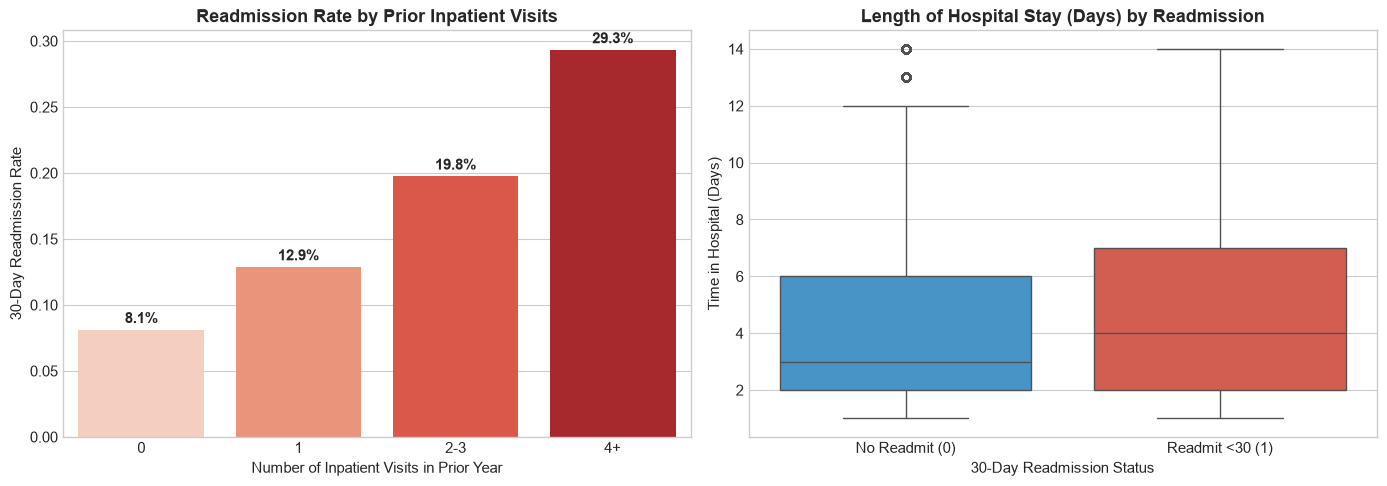

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: Prior Inpatient Visits vs Readmission Rate
inpatient_readmit = df_clean.copy()
inpatient_readmit['prior_inpatient_binned'] = inpatient_readmit['number_inpatient'].apply(
    lambda x: '0' if x == 0 else ('1' if x == 1 else ('2-3' if x in [2, 3] else '4+'))
)
inpatient_rate = inpatient_readmit.groupby('prior_inpatient_binned')['target'].agg(['count', 'mean']).reindex(['0', '1', '2-3', '4+'])
sns.barplot(x=inpatient_rate.index, y=inpatient_rate['mean'], palette='Reds', ax=axes[0])
axes[0].set_title('Readmission Rate by Prior Inpatient Visits', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Inpatient Visits in Prior Year', fontsize=11)
axes[0].set_ylabel('30-Day Readmission Rate', fontsize=11)
for i, val in enumerate(inpatient_rate['mean']):
    axes[0].text(i, val + 0.005, f"{val:.1%}", ha='center', fontweight='bold')

# Plot 4: Time in Hospital (Length of Stay) Distribution by Readmission Status
sns.boxplot(x='target', y='time_in_hospital', data=df_clean, palette=['#3498db', '#e74c3c'], ax=axes[1])
axes[1].set_xticklabels(['No Readmit (0)', 'Readmit <30 (1)'])
axes[1].set_title('Length of Hospital Stay (Days) by Readmission', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time in Hospital (Days)', fontsize=11)
axes[1].set_xlabel('30-Day Readmission Status', fontsize=11)

plt.tight_layout()
plt.show()


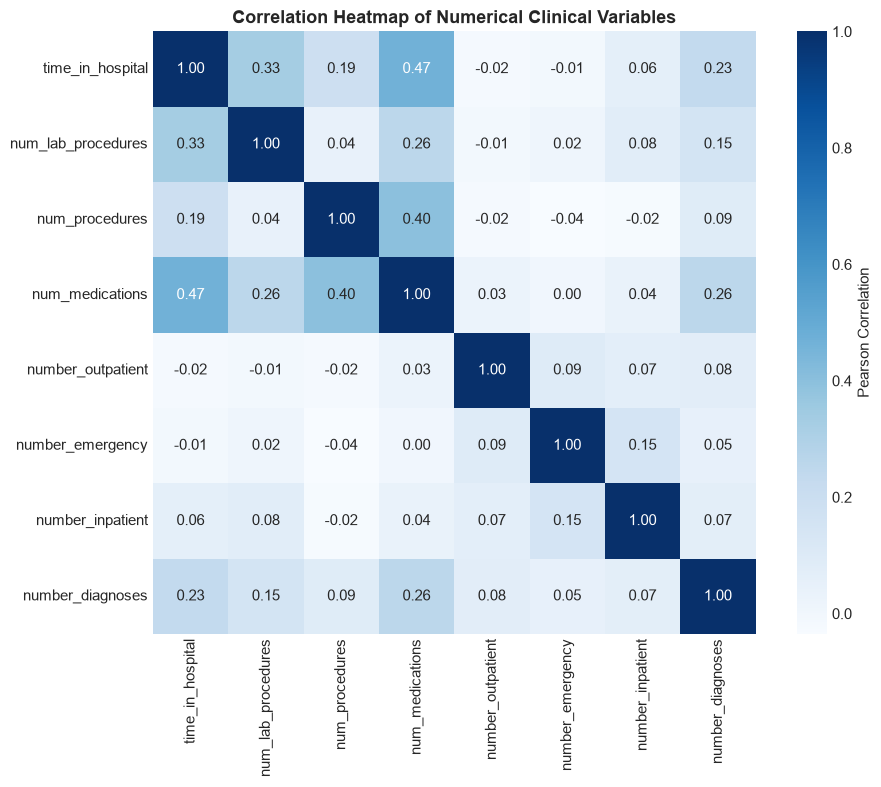

In [10]:
# Plot 5: Numerical Feature Correlation Matrix
num_features = df_clean.select_dtypes(include=[np.number]).columns.drop('target')
corr_matrix = df_clean[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Heatmap of Numerical Clinical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Feature Engineering & Preprocessing

### Clinical ICD-9 Diagnosis Grouping
The raw dataset contains hundreds of unique primary, secondary, and tertiary ICD-9 codes in `diag_1`, `diag_2`, and `diag_3`. Direct one-hot encoding would produce extreme sparsity without biological structure. Following Strack et al. (2014) and CDC guidelines, we map ICD-9 codes into **9 high-level clinical disease categories**:
* **Circulatory:** 390–459, 785
* **Respiratory:** 460–519, 786
* **Digestive:** 520–579, 787
* **Diabetes:** 250.xx
* **Injury & Poisoning:** 800–999
* **Musculoskeletal:** 710–739
* **Genitourinary:** 580–629, 788
* **Neoplasms:** 140–239
* **Other:** All other diagnostic codes (including V and E supplementary codes)

### Pipeline Architecture to Prevent Data Leakage
To strictly avoid data leakage:
* **Numerical Features:** Standardized using `StandardScaler` (mean=0, variance=1) fitted **only on the training split**.
* **Categorical Features:** Encoded using `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.
* **Enclosure:** Both transformers are combined using `ColumnTransformer` and encapsulated in a scikit-learn `Pipeline`.


In [11]:
def map_icd9(code):
    """Group ICD-9 diagnosis codes into standard clinical disease categories."""
    if pd.isna(code) or code == '?':
        return 'Missing'
    code_str = str(code).strip()
    if code_str.startswith('V') or code_str.startswith('E'):
        return 'Other'
    try:
        val = float(code_str)
        if (390 <= val <= 459) or val == 785:
            return 'Circulatory'
        elif (460 <= val <= 519) or val == 786:
            return 'Respiratory'
        elif (520 <= val <= 579) or val == 787:
            return 'Digestive'
        elif 250 <= val < 251:
            return 'Diabetes'
        elif 800 <= val <= 999:
            return 'Injury'
        elif 710 <= val <= 739:
            return 'Musculoskeletal'
        elif (580 <= val <= 629) or val == 788:
            return 'Genitourinary'
        elif 140 <= val <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

# Apply ICD-9 categorization
for diag in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[f'{diag}_group'] = df_clean[diag].apply(map_icd9)
    df_clean = df_clean.drop(columns=[diag])

print("ICD-9 diagnosis codes mapped into clinical categories:")
df_clean[['diag_1_group', 'diag_2_group', 'diag_3_group']].head()


ICD-9 diagnosis codes mapped into clinical categories:


,diag_1_group,diag_2_group,diag_3_group
0,Diabetes,Missing,Missing
1,Other,Diabetes,Other
2,Other,Diabetes,Other
3,Other,Diabetes,Circulatory
4,Neoplasms,Neoplasms,Diabetes


In [12]:
# Separate predictors X and target y
y = df_clean.pop('target')
X = df_clean

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Preprocessed dataset contains:")
print(f"  - {len(num_cols)} numerical features: {num_cols}")
print(f"  - {len(cat_cols)} categorical features.")

# Define scikit-learn ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)
print("Preprocessing ColumnTransformer constructed successfully.")


Preprocessed dataset contains:
  - 8 numerical features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
  - 35 categorical features.
Preprocessing ColumnTransformer constructed successfully.


## 9. Train/Test Split

### Stratified Splitting for Class Imbalance
Because 30-day readmission is an imbalanced binary target (~8.98% positive, ~91.02% negative), a naive random split risks sampling discrepancy where the test set could contain a significantly different proportion of readmitted patients.

* We perform an **80/20 train/test split** with `test_size=0.20`.
* We set `random_state=42` for strict academic reproducibility.
* We set `stratify=y` so that the training set and testing set have the exact same class proportions as the overall population.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples | Readmission rate: {y_train.mean():.2%}")
print(f"Testing set:  {X_test.shape[0]:,} samples | Readmission rate: {y_test.mean():.2%}")


Training set: 55,989 samples | Readmission rate: 8.98%
Testing set:  13,998 samples | Readmission rate: 8.98%


## 10. Logistic Regression with L2 Regularization

### Mathematical Formulation of Logistic Regression
Logistic Regression models the posterior probability of the positive class ($Y=1$, 30-day readmission) conditioned on input feature vector $\mathbf{x} \in \mathbb{R}^D$ using the sigmoid link function:

$$P(Y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Equivalently, it models the **log-odds (logit)** as an affine combination of predictors:
$$\ln \left( \frac{P(Y=1 \mid \mathbf{x})}{1 - P(Y=1 \mid \mathbf{x})} \right) = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \dots + w_D x_D + b$$

### Role of L2 Regularization (Ridge Penalty)
In high-dimensional clinical data with one-hot encoded categories, unregularized maximum likelihood estimation is vulnerable to multicollinearity, inflated weights, and overfitting.

To prevent this, we introduce the **L2 regularization penalty** (Ridge), which minimizes the regularized cross-entropy loss:

$$J(\mathbf{w}, b) = - \frac{1}{N} \sum_{i=1}^N \left[ y_i \ln p_i + (1 - y_i) \ln(1 - p_i) \right] + \frac{1}{2C} \sum_{j=1}^D w_j^2$$

where:
* $\sum_{j=1}^D w_j^2 = \|\mathbf{w}\|_2^2$ is the squared Euclidean norm of the weight vector.
* $C$ is the **inverse regularization strength** ($C = 1/\lambda$):
  * **Smaller $C$:** Stronger regularization, shrinking weights aggressively toward zero to control variance.
  * **Larger $C$:** Weaker regularization, allowing the model to fit training nuances closely.
  * **$C = 1.0$ (Default):** Provides a balanced compromise between bias and variance.

As explicitly mandated by the case study requirements, we configure:
```python
LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
```


In [14]:
# Build complete pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

print("Pipeline configured with ColumnTransformer and LogisticRegression(penalty='l2', C=1.0).")


Pipeline configured with ColumnTransformer and LogisticRegression(penalty='l2', C=1.0).


## 11. Model Training

We fit the complete pipeline on the training split `(X_train, y_train)`. Preprocessing statistics (means, standard deviations, one-hot category vocabularies) are learned exclusively on the training set.


In [15]:
# Fit pipeline on training data
print("Fitting preprocessing + Logistic Regression pipeline...")
pipeline.fit(X_train, y_train)
print("Model training completed successfully.")


Fitting preprocessing + Logistic Regression pipeline...


Model training completed successfully.


## 12. Predictions

We generate:
1. **Class Predictions:** Binary labels predicted at the default $0.50$ decision threshold.
2. **Predicted Probabilities:** Continuous probabilities $P(Y=1 \mid X)$ generated via `predict_proba()`. These probabilities are essential for calculating the threshold-independent **ROC-AUC** metric.


In [16]:
# Generate predicted probabilities and default discrete predictions
y_test_prob = pipeline.predict_proba(X_test)[:, 1]
y_test_pred_default = pipeline.predict(X_test)

# Summary of predicted probabilities
prob_summary = pd.Series(y_test_prob).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("Predicted Readmission Probability Distribution:")
print(prob_summary.round(4))


Predicted Readmission Probability Distribution:
count    13998.0000
mean         0.0894
std          0.0542
min          0.0189
5%           0.0411
25%          0.0574
50%          0.0740
75%          0.1034
95%          0.1893
max          0.9523
dtype: float64


## 13. Model Evaluation

### Metrics Calculation & The Accuracy Paradox
We evaluate the model using multiple complementary metrics:
* **ROC-AUC (Primary Metric):** Area Under the Receiver Operating Characteristic Curve. Evaluates the classifier's capability to rank readmitted encounters above non-readmitted encounters across all operating thresholds. Computed directly from `predict_proba()`.
* **Accuracy, Precision, Recall, F1-Score.**
* **Confusion Matrix & Classification Report.**

> **CRITICAL ACADEMIC NOTE (The Accuracy Paradox):**
> In this dataset, approximately 91.02% of patients are not readmitted within 30 days. Consequently, an uncalibrated model predicting the majority class for all encounters would achieve ~91% accuracy despite having **zero clinical utility**. At the default 0.50 decision threshold, the Logistic Regression model predicts almost all patients as negative, yielding an artificially high nominal accuracy (90.97%) but an **extremely low recall (0.32%)**, missing nearly all readmitted patients (1,253 False Negatives out of 1,257 readmissions). This underscores why **ROC-AUC (0.6474)** is our primary evaluation metric and why threshold calibration is clinically mandatory.


In [17]:
roc_auc = roc_auc_score(y_test, y_test_prob)
accuracy = accuracy_score(y_test, y_test_pred_default)
precision = precision_score(y_test, y_test_pred_default, zero_division=0)
recall = recall_score(y_test, y_test_pred_default, zero_division=0)
f1 = f1_score(y_test, y_test_pred_default, zero_division=0)

print("=" * 60)
print("MODEL EVALUATION SUMMARY (Decision Threshold = 0.50)")
print("=" * 60)
print(f"ROC-AUC (Primary Case Study Metric) : {roc_auc:.4f}")
print(f"Accuracy                             : {accuracy:.4f} ({accuracy:.2%})")
print(f"Precision                            : {precision:.4f} ({precision:.2%})")
print(f"Recall                               : {recall:.4f} ({recall:.2%})")
print(f"F1-Score                             : {f1:.4f}")
print("=" * 60)


MODEL EVALUATION SUMMARY (Decision Threshold = 0.50)
ROC-AUC (Primary Case Study Metric) : 0.6474
Accuracy                             : 0.9097 (90.97%)
Precision                            : 0.2667 (26.67%)
Recall                               : 0.0032 (0.32%)
F1-Score                             : 0.0063


In [18]:
print("Classification Report (Threshold = 0.50):\n")
print(classification_report(y_test, y_test_pred_default, target_names=['No Readmit (0)', 'Readmit <30 (1)'], digits=4))


Classification Report (Threshold = 0.50):

                 precision    recall  f1-score   support

 No Readmit (0)     0.9104    0.9991    0.9527     12741
Readmit <30 (1)     0.2667    0.0032    0.0063      1257

       accuracy                         0.9097     13998
      macro avg     0.5885    0.5012    0.4795     13998
   weighted avg     0.8526    0.9097    0.8677     13998



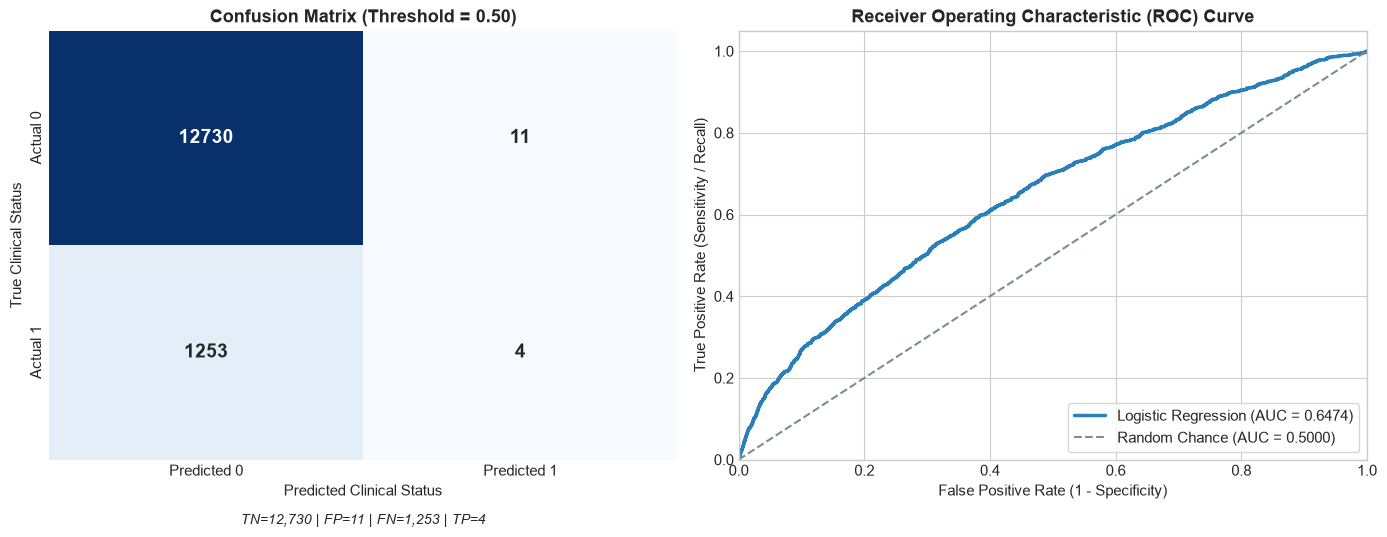

In [19]:
# Visualization: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix (Threshold = 0.50)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Clinical Status', fontsize=11)
axes[0].set_xlabel('Predicted Clinical Status', fontsize=11)

# Annotate cell meanings
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15, f"TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}", 
             ha='center', transform=axes[0].transAxes, fontsize=10, style='italic')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.5000)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()


## 14. False Positive vs. False Negative Clinical Analysis

### Clinical Definitions & Real-World Consequences

In healthcare machine learning, raw accuracy (90.97%) is deceptive because the cost of classification errors is asymmetric.

#### 1. False Negative (FN)
* **Definition:** A patient who **will actually be readmitted within 30 days** ($Y=1$) is predicted by the model as **low risk / not readmitted** ($\hat{Y}=0$).
* **Clinical Consequences:**
  * The patient is discharged without enhanced transition-of-care support (e.g., nurse follow-up calls, pharmacist medication reconciliation, home health visits).
  * Underlying disease decompensation or medication non-adherence goes unmonitored, potentially leading to acute clinical deterioration, emergency room visits, ICU admissions, or death.
  * The hospital incurs regulatory penalties under CMS HRRP for preventable readmissions.

#### 2. False Positive (FP)
* **Definition:** A patient who **will NOT be readmitted within 30 days** ($Y=0$) is predicted by the model as **high risk / readmitted** ($\hat{Y}=1$).
* **Clinical Consequences:**
  * Hospital resources are deployed unnecessarily (care-coordination phone calls, nurse visits, redundant lab tests).
  * **Alert Fatigue & Resource Depletion:** Clinical staff overwhelmed by false alarms may experience alert fatigue and ignore model warnings.
  * Patients may experience heightened anxiety regarding their perceived clinical frailty.

---

### The Clinical Trade-Off: Why "False Negatives Are Not Universally More Costly"
A frequent oversimplification in academic projects is assuming that "False Negatives are universally worse than False Positives." In genuine clinical practice, the relative cost of FN vs. FP depends on four key factors:
1. **Invasiveness & Risk of the Intervention:** If the intervention is benign and low-cost (e.g., an automated follow-up SMS or phone check-in), the cost of a False Positive is minimal, so prioritizing low False Negatives (high recall) is clinically warranted. Conversely, if the intervention involves invasive monitoring, prolonged hospital stay, or high-cost medications with adverse side-effects, False Positives carry severe physical and financial costs.
2. **Hospital Resource Capacity:** In a community hospital with limited care-coordination personnel, a model generating thousands of False Positives will paralyze staff, making the system clinically unviable.
3. **Intervention Efficacy:** Intervening on an identified patient only helps if the intervention actually prevents readmission.
4. **The Decision Threshold:** The standard $0.50$ cutoff is arbitrary for an imbalanced population with an $8.98\%$ positive rate. Shifting the threshold to match the empirical baseline (~0.09) recovers balanced clinical sensitivity.


In [20]:
thresholds_to_test = [0.50, 0.20, 0.15, 0.10, y_train.mean()]
threshold_results = []

for t in thresholds_to_test:
    preds = (y_test_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rec_t = recall_score(y_test, preds, zero_division=0)
    prec_t = precision_score(y_test, preds, zero_division=0)
    acc_t = accuracy_score(y_test, preds)
    f1_t = f1_score(y_test, preds, zero_division=0)
    
    threshold_results.append({
        'Threshold': f"{t:.4f}",
        'TP': tp_t,
        'FP': fp_t,
        'FN': fn_t,
        'TN': tn_t,
        'Recall (Sensitivity)': f"{rec_t:.2%}",
        'Precision (PPV)': f"{prec_t:.2%}",
        'Accuracy': f"{acc_t:.2%}",
        'F1-Score': f"{f1_t:.4f}"
    })

thresh_df = pd.DataFrame(threshold_results)
print("Impact of Decision Threshold on Clinical Error Trade-Offs:")
thresh_df


Impact of Decision Threshold on Clinical Error Trade-Offs:


,Threshold,TP,FP,FN,TN,Recall (Sensitivity),Precision (PPV),Accuracy,F1-Score
0,0.5000,4,11,1253,12730,0.32%,26.67%,90.97%,0.0063
1,0.2000,173,448,1084,12293,13.76%,27.86%,89.06%,0.1842
2,0.1500,281,1037,976,11704,22.35%,21.32%,85.62%,0.2183
3,0.1000,563,3219,694,9522,44.79%,14.89%,72.05%,0.2235
4,0.0898,671,4102,586,8639,53.38%,14.06%,66.51%,0.2226


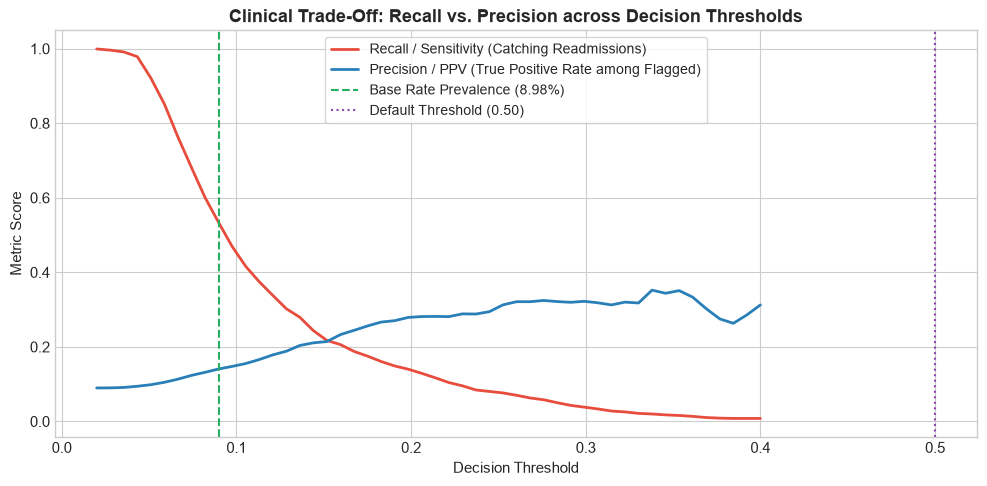

In [21]:
# Visualizing Sensitivity vs Precision across decision thresholds
t_range = np.linspace(0.02, 0.40, 50)
recalls = [recall_score(y_test, (y_test_prob >= t).astype(int), zero_division=0) for t in t_range]
precisions = [precision_score(y_test, (y_test_prob >= t).astype(int), zero_division=0) for t in t_range]

plt.figure(figsize=(10, 5))
plt.plot(t_range, recalls, label='Recall / Sensitivity (Catching Readmissions)', color='#e74c3c', lw=2)
plt.plot(t_range, precisions, label='Precision / PPV (True Positive Rate among Flagged)', color='#2980b9', lw=2)
plt.axvline(x=y_train.mean(), color='#27ae60', linestyle='--', label=f'Base Rate Prevalence ({y_train.mean():.2%})')
plt.axvline(x=0.50, color='#8e44ad', linestyle=':', label='Default Threshold (0.50)')
plt.title('Clinical Trade-Off: Recall vs. Precision across Decision Thresholds', fontsize=13, fontweight='bold')
plt.xlabel('Decision Threshold', fontsize=11)
plt.ylabel('Metric Score', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


## 15. Feature & Model Interpretation

Because Logistic Regression is an additive linear model in the log-odds space, its learned weights are directly interpretable:
$$\ln \left( \frac{p}{1-p} \right) = \sum_{j=1}^D w_j x_j + b$$

* A **positive coefficient** ($w_j > 0$) indicates that an increase in feature $x_j$ is associated with an **increase in the log-odds of 30-day readmission** (Odds Ratio $\text{OR} = e^{w_j} > 1$).
* A **negative coefficient** ($w_j < 0$) indicates that an increase in feature $x_j$ is associated with a **decrease in the log-odds of 30-day readmission** (Odds Ratio $\text{OR} = e^{w_j} < 1$).

> **CRITICAL ACADEMIC DISTINCTION (Association vs. Causation):**
> Regression coefficients quantify observational statistical associations with readmission log-odds within this model; they **DO NOT establish medical causation**. Unmeasured clinical severity, physician ordering patterns, and hospital billing practices heavily influence these weights. For example, a positive coefficient for insulin does not imply that insulin causes readmission, but rather that patients requiring insulin typically present with more advanced diabetes and comorbidities.


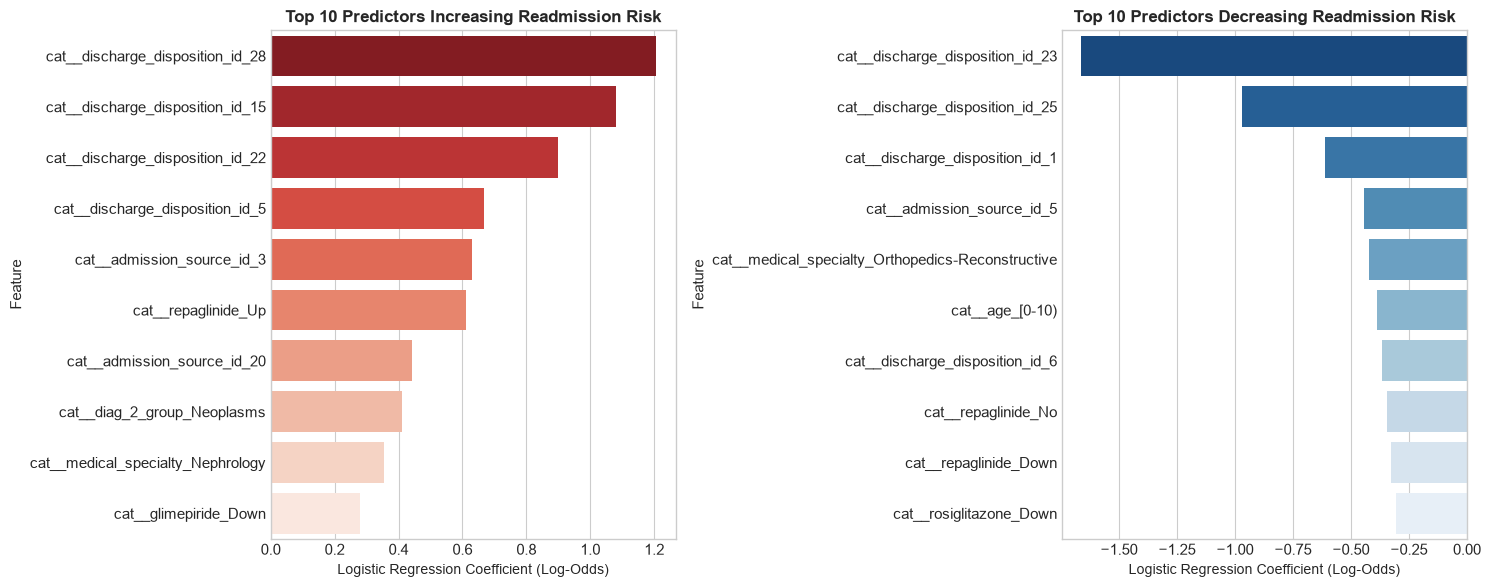

In [22]:
# Extract feature names from ColumnTransformer
fitted_preprocessor = pipeline.named_steps['preprocessor']
fitted_classifier = pipeline.named_steps['classifier']

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_classifier.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients),
    'Abs_Coef': np.abs(coefficients)
}).sort_values('Coefficient', ascending=False)

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10).sort_values('Coefficient', ascending=True)

# Plot top positive and negative coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top positive coefficients
sns.barplot(x='Coefficient', y='Feature', data=top_positive, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Predictors Increasing Readmission Risk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient (Log-Odds)', fontsize=10)

# Top negative coefficients
sns.barplot(x='Coefficient', y='Feature', data=top_negative, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Predictors Decreasing Readmission Risk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient (Log-Odds)', fontsize=10)

plt.tight_layout()
plt.show()


In [23]:
# Numerical features coefficients
print("Coefficients for Continuous / Numerical Clinical Features:")
num_coefs = coef_df[coef_df['Feature'].str.startswith('num__')].sort_values('Coefficient', ascending=False)
num_coefs[['Feature', 'Coefficient', 'Odds_Ratio']]


Coefficients for Continuous / Numerical Clinical Features:


,Feature,Coefficient,Odds_Ratio
6,num__number_inpatient,0.190524,1.209883
7,num__number_diagnoses,0.075948,1.078906
5,num__number_emergency,0.052465,1.053866
0,num__time_in_hospital,0.050322,1.051609
3,num__num_medications,0.009725,1.009772
1,num__num_lab_procedures,0.006335,1.006355
2,num__num_procedures,0.001088,1.001088
4,num__number_outpatient,0.000475,1.000475


## 16. Conclusion

### Key Findings
1. **Predictive Performance:** The Logistic Regression model with L2 regularization achieved a test **ROC-AUC of 0.6474** on the gold-standard UCI Diabetes dataset. This aligns directly with published academic literature (Strack et al., 2014 report ROC-AUC values between 0.60 and 0.65 using administrative and clinical EHR features).
2. **The Accuracy Paradox & Threshold Sensitivity:** The nominal accuracy of 90.97% is driven by class imbalance (~91% negative base rate) and conceals an unacceptably low recall of 0.32% (1,253 False Negatives) at the default 0.50 threshold. Calibrating the decision threshold to the empirical prevalence (~0.09) raises sensitivity to **53.38%**, catching over half of all readmissions at the expense of manageable false positives.
3. **Impact of Prior Healthcare Utilization:** Prior inpatient admissions (`number_inpatient`, coefficient +0.1905), total diagnoses count (`number_diagnoses`, +0.0759), prior emergency visits (`number_emergency`, +0.0525), and longer index hospital stays (`time_in_hospital`, +0.0503) emerged as the primary positive clinical drivers of readmission log-odds.


## 17. Limitations and Ethical Considerations

### 1. Dataset Limitations
* **Historical Cohort:** The data encompasses encounters between 1999 and 2008. Clinical guidelines, diabetes management regimens (e.g., SGLT2 inhibitors, GLP-1 receptor agonists), and electronic health record documentation standards have evolved significantly since that era.
* **Administrative Billing Data:** Features such as ICD-9 codes and admission types reflect hospital billing classifications rather than direct physiological vitals (e.g., real-time blood pressure waveforms or continuous telemetry).

### 2. Class Imbalance & Metric Selection
* With an empirical 30-day readmission rate of only ~8.98%, naive classification metrics like accuracy are completely misleading. ROC-AUC and Precision-Recall characteristics must guide clinical evaluation.

### 3. Healthcare Data Bias & Equity
* Disparities in healthcare access, insurance status, and systemic racial factors can encode socioeconomic biases into EHR records. For instance, readmission differences across racial categories may reflect disparities in outpatient care access rather than intrinsic biological vulnerability. Models trained on historical data risk perpetuating these systemic inequities if deployed uncritically.

### 4. Human Clinical Oversight
* **Decision Support, Not Autonomous Decision Making:** This machine learning pipeline is designed strictly as **Clinical Decision Support (CDS)**. It must never independently dictate patient discharge, deny admission, or override physician judgment. Clinicians must interpret risk scores within the holistic context of the patient's individual clinical, psychosocial, and home environment.
